In [1]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
from typing import Callable, Sequence

In [2]:
class ClassicalCode:
    """
    Classical linear code [[n, k]] defined by a binary parity-check matrix.

    Parameters
    ----------
    H : np.ndarray, shape (m, n)
        Parity-check matrix over F_2.  Stored mod 2.

    Attributes
    ----------
    H       : np.ndarray[int], shape (m, n)
    n       : int  -- number of physical bits
    m       : int  -- number of parity checks  (= n - k)
    k       : int  -- number of logical bits
    dim     : int  -- 2**n, state-space dimension
    S       : list[tuple[int, ...]]  -- all 2**m syndrome labels
    decoder : dict[tuple[int, ...], np.ndarray[int]]
              minimum-weight lookup table: syndrome -> length-n correction bitstring
    """

    _I2: np.ndarray = np.eye(2)
    _X:  np.ndarray = np.array([[0., 1.], [1., 0.]])

    def __init__(self, H: np.ndarray) -> None:
        self.H:       np.ndarray             = np.array(H, dtype=int) % 2
        self.n:       int                    = self.H.shape[1]
        self.m:       int                    = self.H.shape[0]
        self.k:       int                    = self.n - self.m
        self.dim:     int                    = 2 ** self.n
        self.S:       list[tuple[int, ...]]  = list(itertools.product([0, 1], repeat=self.m))
        self.decoder: dict[tuple[int, ...], np.ndarray] = self._build_decoder()

    # ------------------------------------------------------------------
    # Code operations
    # ------------------------------------------------------------------

    def syndrome(self, e: Sequence[int]) -> tuple[int, ...]:
        """
        Parameters
        ----------
        e : Sequence[int], length n -- binary error pattern (0/1 entries)

        Returns
        -------
        tuple[int, ...], length m -- syndrome H e mod 2
        """
        return tuple(int(b) for b in (self.H @ np.array(e, dtype=int)) % 2)

    def _build_decoder(self) -> dict[tuple[int, ...], np.ndarray]:
        """
        Returns
        -------
        dict mapping each syndrome tuple to its minimum-weight correction
        bitstring (np.ndarray[int], length n)
        """
        table: dict[tuple[int, ...], np.ndarray] = {}
        for w in range(self.n + 1):
            for combo in itertools.combinations(range(self.n), w):
                e = np.zeros(self.n, dtype=int)
                for i in combo:
                    e[i] = 1
                s = self.syndrome(e)
                if s not in table:
                    table[s] = e.copy()
            if len(table) == 2 ** self.m:
                break
        return table

    def x_string(self, bits: Sequence[int]) -> np.ndarray:
        """
        Tensor product of single-qubit X gates controlled by a binary string.

        Parameters
        ----------
        bits : Sequence[int], length n -- apply X on position j iff bits[j] == 1

        Returns
        -------
        np.ndarray[complex], shape (dim, dim)
        """
        M = np.array([[1.0]])
        for b in bits:
            M = np.kron(M, self._X if b else self._I2)
        return M

    def R_op(self, s: tuple[int, ...]) -> np.ndarray:
        """
        Recovery (correction) operator for syndrome s: X^{decoder[s]}.

        Parameters
        ----------
        s : tuple[int, ...], length m -- syndrome label (entries in {0, 1})

        Returns
        -------
        np.ndarray[complex], shape (dim, dim)
        """
        return self.x_string(self.decoder[tuple(int(b) % 2 for b in s)])

    def basis_state(self, i: int) -> np.ndarray:
        """
        Pure computational-basis density matrix |i><i|.

        Parameters
        ----------
        i : int -- index in [0, dim)

        Returns
        -------
        np.ndarray[complex], shape (dim, dim)
        """
        rho = np.zeros((self.dim, self.dim), dtype=complex)
        rho[i, i] = 1.0
        return rho

    def to_bits(self, x: int) -> list[int]:
        """
        Integer to n-bit list, MSB first.

        Parameters
        ----------
        x : int -- value in [0, 2**n)

        Returns
        -------
        list[int], length n
        """
        return [(x >> (self.n - 1 - i)) & 1 for i in range(self.n)]

    def P_syndrome(self, sigma: tuple[int, ...]) -> np.ndarray:
        """
        Projector onto computational-basis states whose syndrome equals sigma.

        Parameters
        ----------
        sigma : tuple[int, ...], length m

        Returns
        -------
        np.ndarray[float], shape (dim, dim) -- diagonal projector
        """
        P = np.zeros((self.dim, self.dim))
        for x in range(self.dim):
            if self.syndrome(self.to_bits(x)) == tuple(sigma):
                P[x, x] = 1.0
        return P

    def build_logical_unitary(self) -> np.ndarray:
        """
        Unitary U mapping the physical space C^{2^n} to C^{2^k} tensor C^{2^m}.

        U|x>_phys = |l(x)>_L tensor |s_idx(x)>_S

        where:
          s     = syndrome(x)                       -- syndrome of physical state x
          y     = R(s)|x>                           -- corrected codeword index
          l     = position of y in codespace sorted by integer value
          s_idx = code.S.index(s)                  -- syndrome label index

        U is a real permutation matrix, so U^dagger = U^T.

        Returns
        -------
        np.ndarray[float], shape (dim, dim)
        """
        zero_syn  = tuple(0 for _ in range(self.m))
        dim_S     = 2 ** self.m
        codespace = sorted(y for y in range(self.dim)
                           if self.syndrome(self.to_bits(y)) == zero_syn)
        log_idx   = {y: l for l, y in enumerate(codespace)}

        U   = np.zeros((self.dim, self.dim))
        e_x = np.zeros(self.dim)
        for x in range(self.dim):
            s_x    = self.syndrome(self.to_bits(x))
            e_x[:] = 0.0
            e_x[x] = 1.0
            y      = int(np.argmax(self.R_op(s_x) @ e_x))
            l      = log_idx[y]
            s_idx  = self.S.index(s_x)
            U[l * dim_S + s_idx, x] = 1.0
        return U

    def decoding_table(self) -> dict[tuple[int, ...], list[int]]:
        """Return the decoder as a human-readable dict {syndrome: correction_list}."""
        return {s: list(c) for s, c in self.decoder.items()}

    def __repr__(self) -> str:
        return f"ClassicalCode(n={self.n}, k={self.k}, m={self.m})"


# Default: [3,1,3] repetition code
code = ClassicalCode(np.array([[1, 1, 0],
                                [0, 1, 1]]))
print(code)
print("Decoding table:", code.decoding_table())

ClassicalCode(n=3, k=1, m=2)
Decoding table: {(0, 0): [np.int64(0), np.int64(0), np.int64(0)], (1, 0): [np.int64(1), np.int64(0), np.int64(0)], (1, 1): [np.int64(0), np.int64(1), np.int64(0)], (0, 1): [np.int64(0), np.int64(0), np.int64(1)]}


In [3]:
# ---- Error models ----
#
# An ErrorModel is any callable  f(e, p) -> float  where:
#   e : Sequence[int]  -- binary pattern (length n for physical, length m for syndrome)
#   p : float          -- noise parameter in [0, 1]
#   return : float     -- probability of that pattern
#
# A SyndromeDistFn is a callable  f(p) -> dict[tuple[int,...], float]  returning
# a full distribution over code.S for a given noise parameter p.

ErrorModel     = Callable[[Sequence[int], float], float]
SyndromeDistFn = Callable[[float], dict[tuple[int, ...], float]]


# ------------------------------------------------------------------
# Physical-error models  (applied to the n-bit error pattern e~)
# ------------------------------------------------------------------

def iid_bitflip_error(e: Sequence[int], p: float) -> float:
    """
    i.i.d. bit-flip: each bit independently flipped with probability p.

    Parameters
    ----------
    e : Sequence[int] -- binary error pattern of any length
    p : float         -- bit-flip probability per site

    Returns
    -------
    float -- p^w * (1-p)^(len(e)-w),  where w = Hamming weight of e
    """
    w = int(sum(e))
    n = len(e)
    return p ** w * (1 - p) ** (n - w)


def single_error_model(e: Sequence[int], p: float) -> float:
    """
    At-most-one-error model: prob (1-p) for no error, p/n for each single-bit
    error, 0 for weight >= 2.  Models a channel where at most one bit is faulty.

    Parameters
    ----------
    e : Sequence[int] -- binary error pattern
    p : float         -- total single-error probability in [0, 1]

    Returns
    -------
    float
    """
    w = int(sum(e))
    n = len(e)
    if w == 0:
        return 1.0 - p
    if w == 1:
        return p / n
    return 0.0


def burst_error_model(e: Sequence[int], p: float) -> float:
    """
    Burst-error model: errors form a single contiguous block.
    P(no error) = 1 - p; each distinct contiguous burst is equally probable.

    Parameters
    ----------
    e : Sequence[int] -- binary error pattern
    p : float         -- probability of any burst occurring

    Returns
    -------
    float  (0 for non-contiguous error patterns)
    """
    bits  = list(e)
    n     = len(bits)
    ones  = [i for i, b in enumerate(bits) if b]
    if not ones:
        return 1.0 - p
    L = len(ones)
    if ones != list(range(ones[0], ones[0] + L)):   # not contiguous
        return 0.0
    n_bursts = n * (n + 1) // 2                      # total distinct contiguous blocks
    return p / n_bursts


# ------------------------------------------------------------------
# Syndrome-label distribution factories  (applied to the m-bit syndrome label)
# ------------------------------------------------------------------

def make_iid_syndrome_dist(code: 'ClassicalCode') -> SyndromeDistFn:
    """
    Factory: i.i.d. bit-flip syndrome distribution bound to *code*.
    Each of the m syndrome bits is independently flipped with probability p.

    Parameters
    ----------
    code : ClassicalCode

    Returns
    -------
    SyndromeDistFn -- callable  f(p: float) -> dict[tuple[int,...], float]
    """
    def dist(p: float) -> dict[tuple[int, ...], float]:
        return {e: iid_bitflip_error(e, p) for e in code.S}
    dist.__name__ = 'iid_bitflip_syndrome'
    return dist


def make_perfect_syndrome_dist(code: 'ClassicalCode') -> SyndromeDistFn:
    """
    Factory: noiseless syndrome distribution bound to *code*.
    All weight is on the zero syndrome -- syndrome is always measured correctly.

    Parameters
    ----------
    code : ClassicalCode

    Returns
    -------
    SyndromeDistFn -- callable  f(p: float) -> dict[tuple[int,...], float]
    """
    zero = tuple(0 for _ in range(code.m))
    def dist(p: float) -> dict[tuple[int, ...], float]:
        return {e: (1.0 if e == zero else 0.0) for e in code.S}
    dist.__name__ = 'perfect_syndrome'
    return dist


def make_single_flip_syndrome_dist(code: 'ClassicalCode') -> SyndromeDistFn:
    """
    Factory: at-most-one-flip syndrome distribution bound to *code*.
    Prob (1-p) for no flip, p/m per single-bit syndrome error, 0 for weight >= 2.

    Parameters
    ----------
    code : ClassicalCode

    Returns
    -------
    SyndromeDistFn -- callable  f(p: float) -> dict[tuple[int,...], float]
    """
    def dist(p: float) -> dict[tuple[int, ...], float]:
        result: dict[tuple[int, ...], float] = {}
        for e in code.S:
            w = int(sum(e))
            if w == 0:
                result[e] = 1.0 - p
            elif w == 1:
                result[e] = p / code.m
            else:
                result[e] = 0.0
        return result
    dist.__name__ = 'single_flip_syndrome'
    return dist


# Convenience bindings for the current code
iid_syndrome_dist         = make_iid_syndrome_dist(code)
perfect_syndrome_dist     = make_perfect_syndrome_dist(code)
single_flip_syndrome_dist = make_single_flip_syndrome_dist(code)

print("Physical error models : iid_bitflip_error, single_error_model, burst_error_model")
print("Syndrome dist factories: make_iid_syndrome_dist, make_perfect_syndrome_dist, make_single_flip_syndrome_dist")

Physical error models : iid_bitflip_error, single_error_model, burst_error_model
Syndrome dist factories: make_iid_syndrome_dist, make_perfect_syndrome_dist, make_single_flip_syndrome_dist


In [4]:
# ---- Channel construction via superoperators ----
# Column-major vectorization: rho -> K rho K-dagger becomes (K* kron K) vec(rho).

def to_super(K: np.ndarray) -> np.ndarray:
    """
    Parameters
    ----------
    K : np.ndarray[complex], shape (d, d)

    Returns
    -------
    np.ndarray[complex], shape (d^2, d^2) -- superoperator K* kron K
    """
    return np.kron(K.conj(), K)


def vec(rho: np.ndarray) -> np.ndarray:
    """
    Parameters
    ----------
    rho : np.ndarray[complex], shape (d, d)

    Returns
    -------
    np.ndarray[complex], shape (d^2,) -- column-major vectorisation
    """
    return rho.reshape(-1, order='F')


def unvec(v: np.ndarray, dim: int) -> np.ndarray:
    """
    Parameters
    ----------
    v   : np.ndarray[complex], shape (d^2,)
    dim : int -- d

    Returns
    -------
    np.ndarray[complex], shape (d, d) -- column-major un-vectorisation
    """
    return v.reshape(dim, dim, order='F')


def build_SQ(
    code: ClassicalCode,
    q: float,
    p_error: ErrorModel = iid_bitflip_error,
) -> dict[tuple[int, ...], dict[tuple[int, ...], np.ndarray]]:
    """
    Build the transition superoperator SQ[e_i][e_{i-1}] for one QEC step.


    SQ[ei][eim1] = sum_{e~} p_error(e~, q) * super(R_s X^{e~})
    with  s = (H e~ + e_i + e_{i-1}) mod 2.

    Parameters
    ----------
    code    : ClassicalCode
    q       : float       -- noise parameter passed to p_error
    p_error : ErrorModel  -- physical error model, default iid_bitflip_error

    Returns
    -------
    dict[tuple[int,...], dict[tuple[int,...], np.ndarray[complex]]]
        SQ[e_i][e_{i-1}], each value shape (dim^2, dim^2)
    """
    SQ: dict[tuple[int, ...], dict[tuple[int, ...], np.ndarray]] = {ei: {} for ei in code.S}
    for ei in code.S:
        for eim1 in code.S:
            acc = np.zeros((code.dim ** 2, code.dim ** 2), dtype=complex)
            for et in itertools.product([0, 1], repeat=code.n):
                s   = tuple((np.array(code.syndrome(et)) + np.array(ei) + np.array(eim1)) % 2)
                U   = code.R_op(s) @ code.x_string(et)
                acc += p_error(et, q) * to_super(U)
            SQ[ei][eim1] = acc
    return SQ


def build_all_channels(
    code: ClassicalCode,
    T: int,
    q: float,
    p_error: ErrorModel = iid_bitflip_error,
    syndrome_dist: SyndromeDistFn | None = None,
) -> dict[int, np.ndarray]:
    """
    Build superoperator snapshots channel(t) for t = 0..T.

    channel(t) = sum_{e_1..e_t} prod_i p(e_i) * R(e_t) Q(e_t,e_{t-1}) ... Q(e_2,e_1) R(e_1)

    Parameters
    ----------
    code          : ClassicalCode
    T             : int                   -- number of time steps
    q             : float                 -- noise parameter
    p_error       : ErrorModel            -- physical error model; default iid_bitflip_error
    syndrome_dist : SyndromeDistFn | None -- distribution over syndrome labels;
                                             defaults to make_iid_syndrome_dist(code)

    Returns
    -------
    dict[int, np.ndarray[complex]] -- {t: superoperator of shape (dim^2, dim^2)}
    """
    if syndrome_dist is None:
        syndrome_dist = make_iid_syndrome_dist(code)
    ISUP = np.eye(code.dim ** 2, dtype=complex)
    S    = code.S
    psyn = syndrome_dist(q)
    SR   = {e: to_super(code.R_op(e)) for e in S}
    SQ   = build_SQ(code, q, p_error=p_error)

    chans: dict[int, np.ndarray] = {0: ISUP.copy()}
    C = {e: psyn[e] * SR[e] for e in S}
    chans[1] = sum(SR[e] @ C[e] for e in S)
    for t in range(2, T + 1):
        C        = {ei: psyn[ei] * sum(SQ[ei][eim1] @ C[eim1] for eim1 in S) for ei in S}
        chans[t] = sum(SR[ei] @ C[ei] for ei in S)
    return chans


def make_channel(
    code: ClassicalCode,
    chans: dict[int, np.ndarray],
) -> Callable[[int, np.ndarray], np.ndarray]:
    """
    Wrap cached superoperators as a callable channel.

    Parameters
    ----------
    code  : ClassicalCode
    chans : dict[int, np.ndarray] -- output of build_all_channels

    Returns
    -------
    Callable[[int, np.ndarray], np.ndarray]
        channel(t, rho) -> evolved density matrix of shape (dim, dim)
    """
    return lambda t, rho: unvec(chans[t] @ vec(rho), code.dim)

In [5]:
# ---- Logical-space channel (partial trace over syndrome register) ----
# Formula:
#   Phi_L(t)[rho_L] = Tr_S[ U * Lambda_t(rho_phys) * U^dagger ]
# where:
#   rho_phys = U^dagger (rho_L tensor |e_in><e_in|) U   (embedded in zero-syndrome sector)
#   Lambda_t = sum_{e1...eT} prod p(ei) * Q(eT,eT-1)...Q(e2,e1) * Q(e1, e_in)
#   e_in     = (0,...,0)   (zero syndrome -- initial logical state is a codeword)


def partial_trace_syndrome(sigma: np.ndarray, code: ClassicalCode) -> np.ndarray:
    """
    Partial trace over the syndrome (second) tensor factor of sigma.

    sigma is interpreted as acting on C^{2^k} tensor C^{2^m} with row/col index
    l * 2^m + s_idx.  The syndrome index is contracted:
        (rho_L)[l, l'] = sum_s  sigma[l * 2^m + s,  l' * 2^m + s]

    Parameters
    ----------
    sigma : np.ndarray[complex], shape (dim, dim)
            density matrix in the (logical tensor syndrome) product basis
    code  : ClassicalCode

    Returns
    -------
    np.ndarray[complex], shape (2^k, 2^k) -- reduced logical density matrix
    """
    dim_L = 2 ** code.k
    dim_S = 2 ** code.m
    return np.einsum('iaja->ij', sigma.reshape(dim_L, dim_S, dim_L, dim_S))


def build_logical_channels(
    code: ClassicalCode,
    T: int,
    q: float,
    p_error: ErrorModel = iid_bitflip_error,
    syndrome_dist: SyndromeDistFn | None = None,
) -> dict[int, np.ndarray]:
    """
    Build physical-space superoperator snapshots for the logical channel, t = 0..T.

    Differs from build_all_channels in two ways:
      1. First step uses Q(e1, e_in) with e_in = (0,...,0) instead of R(e1);
         the syndrome evolves freely from step 1 onward.
      2. No trailing R(eT) decode at each snapshot.

    Wrap with make_logical_channel to obtain a callable on the logical space.

    Parameters
    ----------
    code          : ClassicalCode
    T             : int                   -- number of time steps
    q             : float                 -- noise parameter
    p_error       : ErrorModel            -- physical error model; default iid_bitflip_error
    syndrome_dist : SyndromeDistFn | None -- syndrome label distribution;
                                             defaults to make_iid_syndrome_dist(code)

    Returns
    -------
    dict[int, np.ndarray[complex]] -- {t: physical superoperator, shape (dim^2, dim^2)}
    """
    if syndrome_dist is None:
        syndrome_dist = make_iid_syndrome_dist(code)
    ISUP = np.eye(code.dim ** 2, dtype=complex)
    e_in = tuple(0 for _ in range(code.m))
    S    = code.S
    psyn = syndrome_dist(q)
    SQ   = build_SQ(code, q, p_error=p_error)

    chans: dict[int, np.ndarray] = {0: ISUP.copy()}
    C        = {e1: psyn[e1] * SQ[e1][e_in] for e1 in S}   # first step: Q(e1, e_in=0)
    chans[1] = sum(C[e1] for e1 in S)                       # no trailing R(e1)
    for t in range(2, T + 1):
        C        = {ei: psyn[ei] * sum(SQ[ei][eim1] @ C[eim1] for eim1 in S) for ei in S}
        chans[t] = sum(C[et] for et in S)                   # no trailing R(eT)
    return chans


def make_logical_channel(
    code: ClassicalCode,
    chans_L: dict[int, np.ndarray],
    U: np.ndarray,
) -> Callable[[int, np.ndarray], np.ndarray]:
    """
    Wrap physical superoperators as a callable on the 2^k logical space.

    Embeds rho_L into the zero-syndrome codespace sector via U^dagger,
    applies chans_L[t] in the physical space, then rotates back with U
    and partial-traces the syndrome register.

    Parameters
    ----------
    code    : ClassicalCode
    chans_L : dict[int, np.ndarray] -- output of build_logical_channels
    U       : np.ndarray[float], shape (dim, dim) -- code.build_logical_unitary()

    Returns
    -------
    Callable[[int, np.ndarray], np.ndarray]
        logical_channel(t, rho_L) -> rho_L_out of shape (2^k, 2^k)
    """
    dim_S    = 2 ** code.m
    e_in_idx = code.S.index(tuple(0 for _ in range(code.m)))
    zero_syn = np.zeros((dim_S, dim_S))
    zero_syn[e_in_idx, e_in_idx] = 1.0

    def logical_channel(t: int, rho_L: np.ndarray) -> np.ndarray:
        """
        Parameters
        ----------
        t     : int -- time step in [0, T]
        rho_L : np.ndarray[complex], shape (2^k, 2^k) -- logical input density matrix

        Returns
        -------
        np.ndarray[complex], shape (2^k, 2^k) -- logical output density matrix
        """
        rho_phys   = U.T.conj() @ np.kron(rho_L, zero_syn) @ U
        sigma_phys = unvec(chans_L[t] @ vec(rho_phys), code.dim)
        sigma_rot  = U @ sigma_phys @ U.T.conj()
        return partial_trace_syndrome(sigma_rot, code)
    return logical_channel


# ---- Sanity checks ----
U = code.build_logical_unitary()
assert np.allclose(U @ U.T, np.eye(code.dim)), 'U is not unitary'

q_test  = 0.1
Tmax_test = 3
_chans_L  = build_logical_channels(code, Tmax_test, q_test)
_lch      = make_logical_channel(code, _chans_L, U)
_rho_test = np.array([[0.7, 0.0], [0.0, 0.3]], dtype=complex)
assert np.allclose(_lch(0, _rho_test), _rho_test), 'logical_channel(0) is not identity'
print('build_logical_unitary : U is unitary (U @ U.T = I)')
print('make_logical_channel  : t=0 is identity on logical space')

build_logical_unitary : U is unitary (U @ U.T = I)
make_logical_channel  : t=0 is identity on logical space


In [6]:
U = code.build_logical_unitary()
U_dag = U.T.conj()
print(code.x_string([1,1,1]))
M = U @ (0.3 * code.basis_state(0) + 0.7 * code.basis_state(7)) @ U_dag

print(partial_trace_syndrome(M, code))

[[0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]]
[[0.3+0.j 0. +0.j]
 [0. +0.j 0.7+0.j]]


In [7]:
# ---- Non-Markovianity (BLP) measure ----
# trace_norm(diag(p1-p2)) = ||p1-p2||_1 = 2 * total-variation distance for the classical case.
def trace_norm(A):
    return np.sum(np.abs(np.linalg.eigvalsh(A)))

def non_markovian_measure(channel, T, rho1, rho2):
    rho = rho1 - rho2
    measure = 0
    for t in range(1, T):
        measure += max(0, 0.5 * (trace_norm(channel(t, rho)) - trace_norm(channel(t - 1, rho))))

    return measure

In [21]:
# ---- Logical-space basis states and max BLP measure ----
dim_L = 2 ** code.k

def logical_basis_state(l: int) -> np.ndarray:
    """Pure logical-basis density matrix |l><l|, shape (2^k, 2^k)."""
    rho = np.zeros((dim_L, dim_L), dtype=complex)
    rho[l, l] = 1.0
    return rho


def max_measure(
    code: ClassicalCode,
    T: int,
    q: float,
    p_error: ErrorModel = iid_bitflip_error,
    syndrome_dist: SyndromeDistFn | None = None,
) -> tuple[float, tuple[int, int]]:
    """
    Maximum non-Markovian measure over all pairs of logical basis states.

    Parameters
    ----------
    code          : ClassicalCode
    T             : int
    q             : float
    p_error       : ErrorModel
    syndrome_dist : SyndromeDistFn | None

    Returns
    -------
    tuple[float, tuple[int, int]] -- (max_measure_value, (i, j))
    """
    chans_L = build_logical_channels(code, T, q,
                                     p_error=p_error,
                                     syndrome_dist=syndrome_dist)
    lch = make_logical_channel(code, chans_L, U)
    best_val, best_pair = non_markovian_measure(lch, T, logical_basis_state(0), logical_basis_state(1)), (0,1)
    #best_val, best_pair = -1.0, None
    #for i in range(dim_L):
    #    for j in range(i + 1, dim_L):
    #        v = non_markovian_measure(lch, T,
    #                                  logical_basis_state(i),
    #                                  logical_basis_state(j))
    #        if v > best_val:
    #            best_val, best_pair = v, (i, j)
    return best_val, best_pair

T = 12
q = 0.1
val, (i, j) = max_measure(code, T, q)
print(f"code: n={code.n}, k={code.k}   T={T}   q={q}")
print(f"max non-Markovian measure (logical) = {val:.6f}")
print(f"optimal logical-state pair: |{i}> vs |{j}>")

code: n=3, k=1   T=12   q=0.1
max non-Markovian measure (logical) = 0.000000
optimal logical-state pair: |0> vs |1>


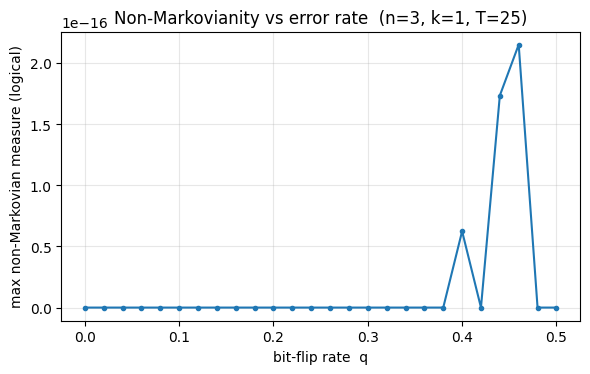

In [22]:
# ---- Sweep the bit-flip rate q and plot the maximised logical measure ----
T  = 25
qs = np.linspace(0.0, 0.5, 26)
vals = [max_measure(code, T, q)[0] for q in qs]

plt.figure(figsize=(6, 4))
plt.plot(qs, vals, marker='o', ms=3)
plt.xlabel('bit-flip rate  q')
plt.ylabel('max non-Markovian measure (logical)')
plt.title(f'Non-Markovianity vs error rate  (n={code.n}, k={code.k}, T={T})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

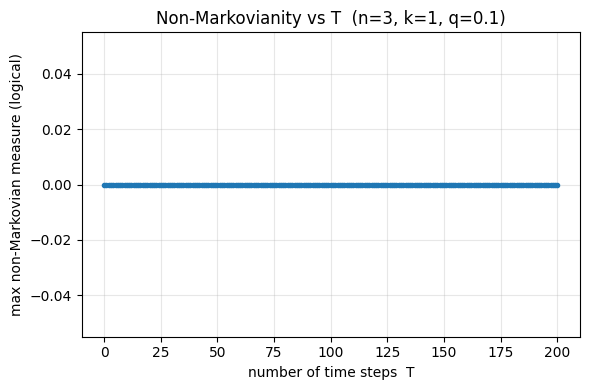

In [28]:
# ---- Measure vs number of time steps T (at fixed q) ----
q    = 0.1
Tmax = 200
_chans30 = build_logical_channels(code, Tmax, q)
channel  = make_logical_channel(code, _chans30, U)


def max_measure_fixed(
    code: ClassicalCode,
    channel: Callable[[int, np.ndarray], np.ndarray],
    T: int,
) -> float:
    """
    Max non-Markovian measure over logical basis-state pairs, using a prebuilt channel.

    Parameters
    ----------
    code    : ClassicalCode
    channel : Callable[[int, np.ndarray], np.ndarray]
    T       : int

    Returns
    -------
    float
    """
    best = -1.0
    for i in range(dim_L):
        for j in range(i + 1, dim_L):
            best = max(best, non_markovian_measure(channel, T,
                                                    logical_basis_state(i),
                                                    logical_basis_state(j)))
    return best

Ts   = list(range(0, Tmax + 1))
vals = [max_measure_fixed(code, channel, T) for T in Ts]

plt.figure(figsize=(6, 4))
plt.plot(Ts, vals, marker='o', ms=3)
plt.xlabel('number of time steps  T')
plt.ylabel('max non-Markovian measure (logical)')
plt.title(f'Non-Markovianity vs T  (n={code.n}, k={code.k}, q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
for val in vals:
    if val != 0:
        print(val)

[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
[np.float64(0.6316369215488), np.float64(-0.6316369215488)]
[[ 0.63163692+0.j  0.        +0.j]
 [ 0.        +0.j -0.63163692+0.j]]


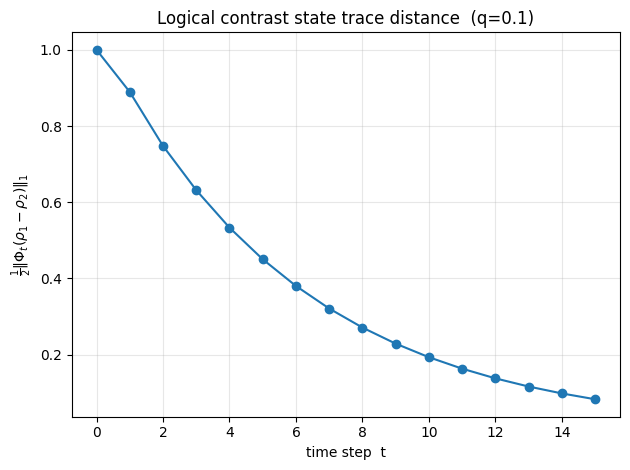

In [11]:
q = 0.1
Tmax = 15
_chans_f = build_logical_channels(code, Tmax, q)
channel  = make_logical_channel(code, _chans_f, U)

# contrast state rho1 - rho2  (traceless Hermitian)
rho = logical_basis_state(0) - logical_basis_state(1)

print(rho)
M_out = channel(3, rho)
print([M_out[idx][idx].real for idx in range(dim_L)])
print(channel(3, rho))

ts   = list(range(0, Tmax + 1))
dist = [0.5 * trace_norm(channel(t, rho)) for t in ts]

plt.plot(ts, dist, marker='o')
plt.xlabel('time step  t')
plt.ylabel(r'$\frac{1}{2}\|\Phi_t(\rho_1-\rho_2)\|_1$')
plt.title(f'Logical contrast state trace distance  (q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

initial D = 1.000000


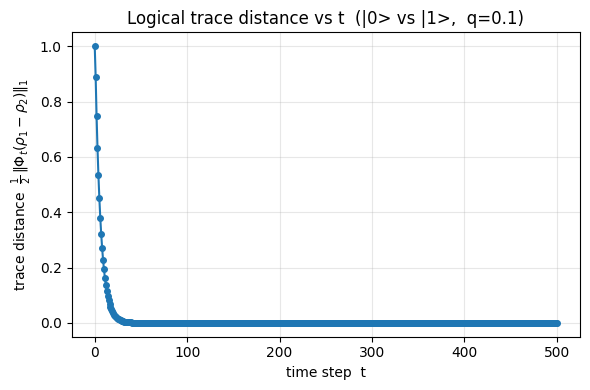

In [35]:
# ---- Raw trace distance vs t for the optimal logical state pair ----
# D(t) = 1/2 ||Phi_t(rho1-rho2)||_1.
# Markovian (CP-divisible) dynamics => D(t) monotonically non-increasing.
q    = 0.1
Tmax = 500
_chans_8 = build_logical_channels(code, Tmax, q)
channel  = make_logical_channel(code, _chans_8, U)

i, j  = 0, 1
delta = logical_basis_state(i) - logical_basis_state(j)
print(f"initial D = {0.5 * trace_norm(delta):.6f}")
ts   = list(range(0, Tmax + 1))
dist = [0.5 * trace_norm(channel(t, delta)) for t in ts]

plt.figure(figsize=(6, 4))
plt.plot(ts, dist, marker='o', ms=4)
plt.xlabel('time step  t')
plt.ylabel(r'trace distance  $\frac{1}{2}\,\|\Phi_t(\rho_1-\rho_2)\|_1$')
plt.title(f'Logical trace distance vs t  (|{i}> vs |{j}>,  q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#for t, d in zip(ts, dist):
#    print(f"t={t:2d}  D={d:.6f}")

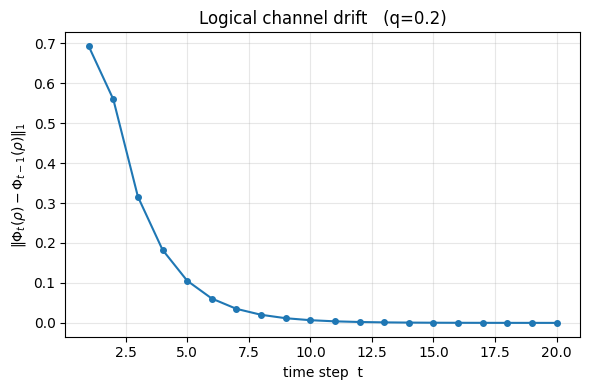

t= 1  ||dPhi(rho)||_1=0.692480
t= 2  ||dPhi(rho)||_1=0.559503
t= 3  ||dPhi(rho)||_1=0.315630
t= 4  ||dPhi(rho)||_1=0.182766
t= 5  ||dPhi(rho)||_1=0.105500
t= 6  ||dPhi(rho)||_1=0.060912
t= 7  ||dPhi(rho)||_1=0.035168
t= 8  ||dPhi(rho)||_1=0.020304
t= 9  ||dPhi(rho)||_1=0.011723
t=10  ||dPhi(rho)||_1=0.006768
t=11  ||dPhi(rho)||_1=0.003908
t=12  ||dPhi(rho)||_1=0.002256
t=13  ||dPhi(rho)||_1=0.001303
t=14  ||dPhi(rho)||_1=0.000752
t=15  ||dPhi(rho)||_1=0.000434
t=16  ||dPhi(rho)||_1=0.000251
t=17  ||dPhi(rho)||_1=0.000145
t=18  ||dPhi(rho)||_1=0.000084
t=19  ||dPhi(rho)||_1=0.000048
t=20  ||dPhi(rho)||_1=0.000028


In [13]:
# ---- Channel drift:  ||Phi_t(rho) - Phi_{t-1}(rho)||_1 ----
q    = 0.2
Tmax = 20
_chans_0b = build_logical_channels(code, Tmax, q)
channel   = make_logical_channel(code, _chans_0b, U)

rho = logical_basis_state(0) - logical_basis_state(1)

ts   = list(range(1, Tmax + 1))
diff = [trace_norm(channel(t, rho) - channel(t - 1, rho)) for t in ts]

plt.figure(figsize=(6, 4))
plt.plot(ts, diff, marker='o', ms=4)
plt.xlabel('time step  t')
plt.ylabel(r'$\|\Phi_t(\rho) - \Phi_{t-1}(\rho)\|_1$')
plt.title(f'Logical channel drift   (q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for t, d in zip(ts, diff):
    print(f"t={t:2d}  ||dPhi(rho)||_1={d:.6f}")

In [14]:
# ---- Model B: QEC channel that decodes the input syndrome sector first ----
p = 0.1

def channel_one_step(
    code: ClassicalCode,
    rho: np.ndarray,
    p: float,
    p_error: ErrorModel = iid_bitflip_error,
    syndrome_dist: SyndromeDistFn | None = None,
) -> np.ndarray:
    """
    One variant-A QEC cycle that decodes the input syndrome first (e0 = syndrome(rho)).
    Kraus operator: K = R(e1) R(s) X^{e~} R(e0),  s = syndrome(e~) + e1 + e0.

    Parameters
    ----------
    code          : ClassicalCode
    rho           : np.ndarray[complex], shape (dim, dim) -- input density matrix
    p             : float              -- noise parameter
    p_error       : ErrorModel         -- physical error model, default iid_bitflip_error
    syndrome_dist : SyndromeDistFn | None -- syndrome label distribution; defaults to iid

    Returns
    -------
    np.ndarray[complex], shape (dim, dim)
    """
    if syndrome_dist is None:
        syndrome_dist = make_iid_syndrome_dist(code)
    psyn = syndrome_dist(p)
    out  = np.zeros((code.dim, code.dim), dtype=complex)
    for e0 in code.S:
        P    = code.P_syndrome(e0)
        rho0 = P @ rho @ P
        if not np.any(rho0):
            continue
        Re0 = code.R_op(e0)
        for e1 in code.S:
            pe1 = psyn[e1]
            for et in itertools.product([0, 1], repeat=code.n):
                pet = p_error(et, p)
                s   = tuple((np.array(code.syndrome(et)) + np.array(e1) + np.array(e0)) % 2)
                K   = code.R_op(e1) @ code.R_op(s) @ code.x_string(et) @ Re0
                out += pe1 * pet * (K @ rho0 @ K.conj().T)
    return out


def build_all_channels_B(
    code: ClassicalCode,
    T: int,
    p: float,
    p_error: ErrorModel = iid_bitflip_error,
    syndrome_dist: SyndromeDistFn | None = None,
) -> dict[int, np.ndarray]:
    """
    Multi-step channel (variant B): decodes input syndrome per sector, then
    applies the same transfer-matrix recursion as build_all_channels.

    Parameters
    ----------
    code          : ClassicalCode
    T             : int
    p             : float
    p_error       : ErrorModel
    syndrome_dist : SyndromeDistFn | None

    Returns
    -------
    dict[int, np.ndarray[complex]] -- {t: superoperator of shape (dim^2, dim^2)}
    """
    if syndrome_dist is None:
        syndrome_dist = make_iid_syndrome_dist(code)
    ISUP = np.eye(code.dim ** 2, dtype=complex)
    SQ   = build_SQ(code, p, p_error=p_error)
    SR   = {e:   to_super(code.R_op(e))       for e   in code.S}
    Pp   = {sig: to_super(code.P_syndrome(sig)) for sig in code.S}
    psyn = syndrome_dist(p)

    chans: dict[int, np.ndarray] = {0: ISUP.copy()}
    C = {sig: {e1: psyn[e1] * (SQ[e1][sig] @ SR[sig]) for e1 in code.S} for sig in code.S}
    snap = lambda C: sum((sum(SR[ei] @ C[sig][ei] for ei in code.S)) @ Pp[sig] for sig in code.S)
    chans[1] = snap(C)
    for t in range(2, T + 1):
        C = {sig: {ei: psyn[ei] * sum(SQ[ei][eim1] @ C[sig][eim1] for eim1 in code.S)
                   for ei in code.S}
             for sig in code.S}
        chans[t] = snap(C)
    return chans


# verify channel(1) coincides with channel_one_step for every basis input
chans_B  = build_all_channels_B(code, 12, p)
_maxdiff = max(
    np.linalg.norm(
        unvec(chans_B[1] @ vec(code.basis_state(x)), code.dim)
        - channel_one_step(code, code.basis_state(x), p)
    )
    for x in range(code.dim)
)
print(f"max |channel(1) - channel_one_step| over basis states = {_maxdiff:.2e}")

max |channel(1) - channel_one_step| over basis states = 3.33e-16


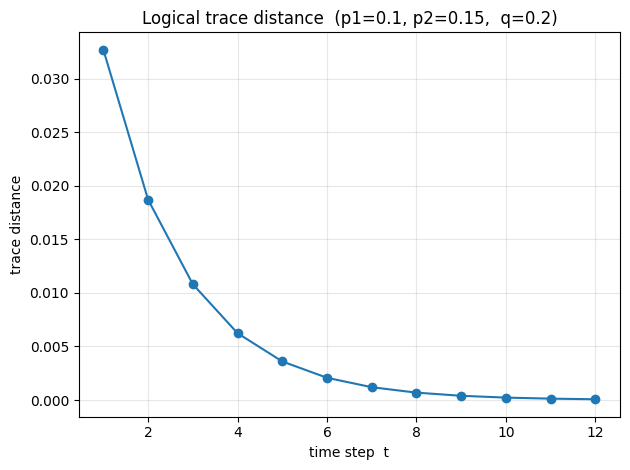

In [15]:
def input_state(code: ClassicalCode, p: float) -> np.ndarray:
    """
    Logical codeword mixture: (1-p)|0>_L<0|_L + p|1>_L<1|_L.

    Parameters
    ----------
    code : ClassicalCode
    p    : float -- mixing parameter in [0, 1]

    Returns
    -------
    np.ndarray[complex], shape (2^k, 2^k)
    """
    return (1 - p) * logical_basis_state(0) + p * logical_basis_state(1)

p1 = 0.1
p2 = 0.15
rho1 = input_state(code, p1)
rho2 = input_state(code, p2)
Tmax = 12
ts   = list(range(1, Tmax + 1))

dist_vals = [0.5 * trace_norm(channel(t, rho1 - rho2)) for t in ts]

plt.plot(ts, dist_vals, marker='o')
plt.xlabel('time step  t')
plt.ylabel(r'trace distance')
plt.title(f'Logical trace distance  (p1={p1}, p2={p2},  q=0.2)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# ---- Maximise the BLP non-Markovian measure over (p1, p2) ----
q    = 0.1
Tmax = 15
_chans_30 = build_logical_channels(code, Tmax, q)
channel   = make_logical_channel(code, _chans_30, U)


def blp_pair(
    code: ClassicalCode,
    channel: Callable[[int, np.ndarray], np.ndarray],
    T: int,
    p1: float,
    p2: float,
) -> tuple[float, float]:
    """
    Parameters
    ----------
    code    : ClassicalCode
    channel : Callable[[int, np.ndarray], np.ndarray] -- logical channel
    T       : int
    p1, p2  : float -- mixing parameters for the two logical input states

    Returns
    -------
    tuple[float, float] -- (BLP measure, largest single positive step)
    """
    rho   = input_state(code, p1) - input_state(code, p2)
    D     = [0.5 * trace_norm(channel(t, rho)) for t in range(T + 1)]
    steps = [D[t] - D[t - 1] for t in range(1, T + 1)]
    return sum(s for s in steps if s > 0), max(steps)

grid = np.linspace(0, 1, 51)
best, best_pair, best_step = -1.0, None, -np.inf
for p1 in grid:
    for p2 in grid:
        if p1 == p2:
            continue
        blp, mx = blp_pair(code, channel, Tmax, p1, p2)
        if blp > best:
            best, best_pair = blp, (round(float(p1), 3), round(float(p2), 3))
        best_step = max(best_step, mx)

print(f"max BLP measure over (p1, p2)           = {best:.3e}   at {best_pair}")
print(f"largest positive gradient (any pair, t) = {best_step:.3e}")
print("  > 0  => a revival (backflow) exists;  <= 0  => D(t) decays monotonically")

max BLP measure over (p1, p2)           = 0.000e+00   at (0.0, 0.02)
largest positive gradient (any pair, t) = -3.058e-04
  > 0  => a revival (backflow) exists;  <= 0  => D(t) decays monotonically


In [17]:
Tmax = 5

rho_L_0    = input_state(code, 0)
rho_final_0 = channel(Tmax, rho_L_0)
p_flip = rho_final_0[1][1].real   # prob |0>_L -> |1>_L

rho_L_1    = input_state(code, 1)
rho_final_1 = channel(Tmax, rho_L_1)
q_flip = rho_final_1[0][0].real   # prob |1>_L -> |0>_L

A_T = np.array([[1 - p_flip, q_flip], [p_flip, 1 - q_flip]])
print(A_T)

[[0.72515517 0.27484483]
 [0.27484483 0.72515517]]


In [18]:
rho_test = input_state(code, 0.1)
print([channel(Tmax, rho_test)[idx][idx].real for idx in (0, 1)])

print(A_T @ np.array([0.9, 0.1]))

[np.float64(0.6801241349765407), np.float64(0.3198758650234598)]
[0.68012413 0.31987587]


In [19]:
def stochastic_matrix(
    code: ClassicalCode,
    t: int,
    channel: Callable[[int, np.ndarray], np.ndarray],
) -> np.ndarray:
    """
    2x2 stochastic matrix of the logical channel.

    Column 0: |0>_L -> (prob stay, prob flip)
    Column 1: |1>_L -> (prob flip, prob stay)

    Parameters
    ----------
    code    : ClassicalCode
    t       : int
    channel : Callable[[int, np.ndarray], np.ndarray] -- logical channel

    Returns
    -------
    np.ndarray[float], shape (2, 2) -- column-stochastic transfer matrix
    """
    p = channel(t, input_state(code, 0))[1][1].real   # |0>_L -> |1>_L
    q = channel(t, input_state(code, 1))[0][0].real   # |1>_L -> |0>_L
    return np.array([[1 - p, q], [p, 1 - q]])


tol = 1e-9

T     = 12
A_T   = stochastic_matrix(code, T,     channel)
A_t_1 = stochastic_matrix(code, T - 1, channel)

M = A_T @ np.linalg.inv(A_t_1)
print(M)

print(np.abs(M[0][0] + M[1][0] - 1.0) < tol)
print(np.abs(M[0][1] + M[1][1] - 1.0) < tol)

[[0.92218105 0.07781895]
 [0.07781895 0.92218105]]
True
True


In [20]:
# ---- Sweep T and check M = A_T @ inv(A_{T-1}) is a valid stochastic matrix ----
Tmax = 20
q    = 0.2
_chans_81 = build_logical_channels(code, Tmax, q)
channel   = make_logical_channel(code, _chans_81, U)

tol     = 1e-9
flagged = []

print(f"q={q}   checking M(T) = A_T @ inv(A_(T-1)) for T = 2..{Tmax}\n")
for T in range(2, Tmax + 1):
    A_T   = stochastic_matrix(code, T,     channel)
    A_t_1 = stochastic_matrix(code, T - 1, channel)
    M = (A_T @ np.linalg.inv(A_t_1)).real

    col_sums  = M.sum(axis=0)
    nonneg_ok = np.all(M >= -tol)
    colsum_ok = np.allclose(col_sums, 1.0, atol=tol)
    valid     = nonneg_ok and colsum_ok

    status = "OK " if valid else "BAD"
    print(f"T={T:2d}  {status}  min_entry={M.min():+.6f}  col_sums={np.round(col_sums, 6)}")

    if not valid:
        reasons = []
        if not nonneg_ok:
            reasons.append(f"negative entry (min={M.min():.3e})")
        if not colsum_ok:
            reasons.append(f"col sums {np.round(col_sums, 6)} != 1")
        flagged.append((T, M.copy(), "; ".join(reasons)))

print()
if not flagged:
    print(f"All time steps T = 2..{Tmax} give a valid stochastic matrix.")
else:
    print(f"{len(flagged)} time step(s) FAILED:")
    for T, M_bad, reason in flagged:
        print(f"  -> T={T}: {reason}")
        print(f"     M =\n{np.array2string(M_bad, prefix='         ')}")

q=0.2   checking M(T) = A_T @ inv(A_(T-1)) for T = 2..20

T= 2  OK   min_entry=+0.213956  col_sums=[1. 1.]
T= 3  OK   min_entry=+0.210978  col_sums=[1. 1.]
T= 4  OK   min_entry=+0.211346  col_sums=[1. 1.]
T= 5  OK   min_entry=+0.211321  col_sums=[1. 1.]
T= 6  OK   min_entry=+0.211325  col_sums=[1. 1.]
T= 7  OK   min_entry=+0.211324  col_sums=[1. 1.]
T= 8  OK   min_entry=+0.211324  col_sums=[1. 1.]
T= 9  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=10  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=11  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=12  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=13  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=14  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=15  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=16  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=17  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=18  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=19  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=20  OK   min_entry=+0.211324  col_sums=[1. 1.]

All time s